# Customer Segmentation & Predictive Analytics
### Online Retail Dataset

In [1]:
!pip -q install openpyxl plotly scikit-learn

import warnings
warnings.filterwarnings("ignore")

import io
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from google.colab import files
from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


## 2. Upload the Dataset

In [2]:
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file was uploaded. Please upload the Online Retail dataset.")

file_name = next(iter(uploaded))
file_bytes = uploaded[file_name]

if file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(io.BytesIO(file_bytes))
elif file_name.lower().endswith(".csv"):
    # utf-8-sig handles common exported CSV files
    try:
        df = pd.read_csv(io.BytesIO(file_bytes), encoding="utf-8-sig")
    except UnicodeDecodeError:
        df = pd.read_csv(io.BytesIO(file_bytes), encoding="latin1")
else:
    raise ValueError("Please upload an Excel (.xlsx/.xls) or CSV (.csv) file.")

print(f"✅ Uploaded file: {file_name}")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Saving Online Retail.xlsx to Online Retail.xlsx
✅ Uploaded file: Online Retail.xlsx
📊 Shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic numerical summary:")
display(df.describe(include="all").T)


Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:


,Data Type
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object



Missing values:


,Missing Values
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0



Duplicate rows: 5268

Basic numerical summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Understanding

The Online Retail data contains transaction-level information such as invoice number, product, quantity, invoice date, unit price, customer ID, and country.

Before modeling, we:
1. remove duplicate rows
2. remove transactions without Customer ID
3. remove cancelled invoices
4. remove non-positive quantity and price records
5. convert date fields to datetime
6. create transaction value = Quantity × UnitPrice

In [4]:
# ============================================================
# 4. DATA CLEANING / PREPROCESSING
# ============================================================
df_clean = df.copy()

# Standardize column names
df_clean.columns = [str(c).strip() for c in df_clean.columns]

# Required columns for this practical
required_cols = [
    "InvoiceNo", "Quantity", "InvoiceDate",
    "UnitPrice", "CustomerID"
]
missing_required = [c for c in required_cols if c not in df_clean.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Remove exact duplicate transactions
before_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed_duplicates = before_duplicates - len(df_clean)

# Convert date
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

# Convert numeric fields safely
df_clean["Quantity"] = pd.to_numeric(df_clean["Quantity"], errors="coerce")
df_clean["UnitPrice"] = pd.to_numeric(df_clean["UnitPrice"], errors="coerce")
df_clean["CustomerID"] = pd.to_numeric(df_clean["CustomerID"], errors="coerce")

# Missing values needed for customer analytics
before_missing = len(df_clean)
df_clean = df_clean.dropna(
    subset=["CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice"]
)
removed_missing = before_missing - len(df_clean)

# Cancellation / return handling:
# UCI Online Retail cancellations are commonly represented by InvoiceNo beginning with 'C'.
before_cancel = len(df_clean)
cancel_mask = df_clean["InvoiceNo"].astype(str).str.upper().str.startswith("C")
df_clean = df_clean.loc[~cancel_mask].copy()
removed_cancel = before_cancel - len(df_clean)

# Keep valid sales transactions
before_invalid = len(df_clean)
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()
removed_invalid = before_invalid - len(df_clean)

# Transaction value
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("CLEANING SUMMARY")
print("-" * 55)
print(f"Original rows                 : {len(df):,}")
print(f"Duplicate rows removed        : {removed_duplicates:,}")
print(f"Rows with required NA removed : {removed_missing:,}")
print(f"Cancelled invoices removed    : {removed_cancel:,}")
print(f"Invalid quantity/price removed: {removed_invalid:,}")
print(f"Final clean transactions      : {len(df_clean):,}")
print(f"Unique customers              : {df_clean['CustomerID'].nunique():,}")

display(df_clean.head())


CLEANING SUMMARY
-------------------------------------------------------
Original rows                 : 541,909
Duplicate rows removed        : 5,268
Rows with required NA removed : 135,037
Cancelled invoices removed    : 8,872
Invalid quantity/price removed: 40
Final clean transactions      : 392,692
Unique customers              : 4,338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


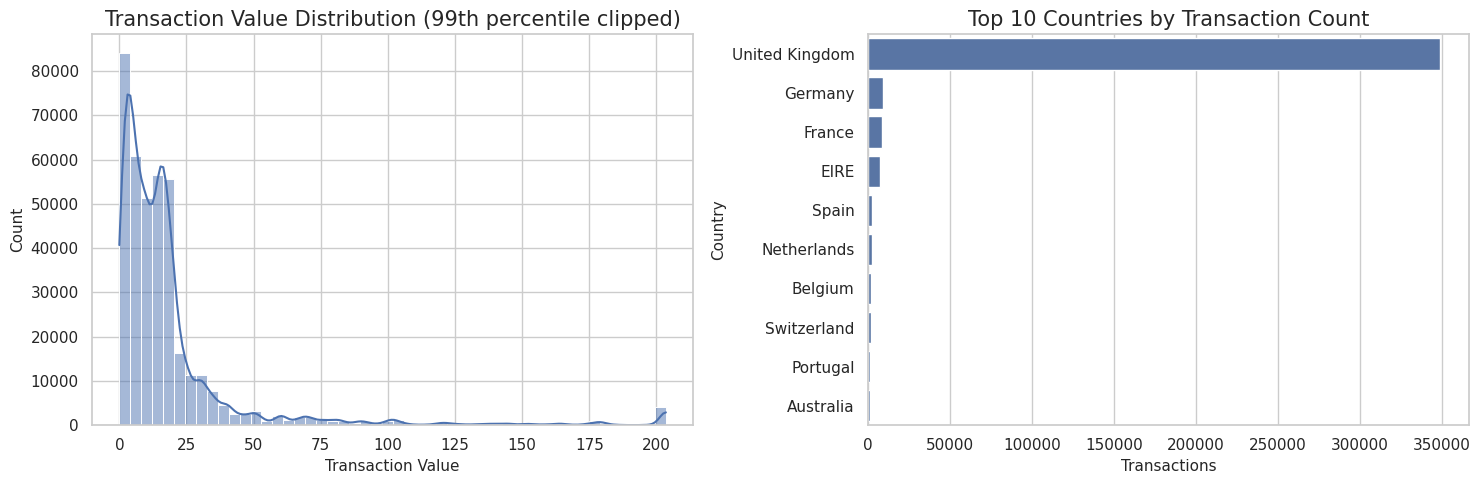

In [5]:
# ============================================================
# 5. CLEANED DATA OVERVIEW
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean["TotalAmount"].clip(upper=df_clean["TotalAmount"].quantile(0.99)),
             bins=50, kde=True, ax=axes[0])
axes[0].set_title("Transaction Value Distribution (99th percentile clipped)")
axes[0].set_xlabel("Transaction Value")

country_counts = df_clean["Country"].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, ax=axes[1])
axes[1].set_title("Top 10 Countries by Transaction Count")
axes[1].set_xlabel("Transactions")
axes[1].set_ylabel("Country")

plt.tight_layout()
plt.show()


## 4. Customer-Level Feature Engineering

We transform transaction-level data into one row per customer.

### Features used
- **Recency:** days since the customer's most recent purchase
- **Frequency:** number of unique invoices
- **Monetary Value:** total amount spent
- **Average Transaction Value**
- **Total Quantity Purchased**
- **Average Quantity per Invoice**
- **Purchase Frequency:** invoices per active year
- **Active Days:** time between first and last purchase

These features provide a compact representation of customer purchasing behavior.

In [6]:
# ============================================================
# 6. CUSTOMER-LEVEL FEATURE ENGINEERING
# ============================================================
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_df = (
    df_clean.groupby("CustomerID")
    .agg(
        LastPurchaseDate=("InvoiceDate", "max"),
        FirstPurchaseDate=("InvoiceDate", "min"),
        Frequency=("InvoiceNo", "nunique"),
        MonetaryValue=("TotalAmount", "sum"),
        TotalQuantity=("Quantity", "sum"),
        AvgQuantity=("Quantity", "mean"),
    )
    .reset_index()
)

customer_df["Recency"] = (
    reference_date - customer_df["LastPurchaseDate"]
).dt.days

customer_df["ActiveDays"] = (
    customer_df["LastPurchaseDate"] - customer_df["FirstPurchaseDate"]
).dt.days + 1

customer_df["AvgTransactionValue"] = (
    customer_df["MonetaryValue"] / customer_df["Frequency"]
)

customer_df["PurchaseFrequency"] = (
    customer_df["Frequency"] / (customer_df["ActiveDays"] / 365.25)
).replace([np.inf, -np.inf], np.nan)

customer_df["PurchaseFrequency"] = customer_df["PurchaseFrequency"].fillna(
    customer_df["Frequency"]
)

feature_cols = [
    "Recency", "Frequency", "MonetaryValue",
    "AvgTransactionValue", "TotalQuantity",
    "AvgQuantity", "PurchaseFrequency", "ActiveDays"
]

customer_df = customer_df[["CustomerID"] + feature_cols].dropna().copy()

print(f"Customer-level dataset: {customer_df.shape[0]:,} customers")
display(customer_df.head())
display(customer_df[feature_cols].describe().T)


Customer-level dataset: 4,338 customers


,CustomerID,Recency,Frequency,MonetaryValue,AvgTransactionValue,TotalQuantity,AvgQuantity,PurchaseFrequency,ActiveDays
0,12346.0,326,1,77183.60,77183.600000,74215,74215.000000,365.250000,1
1,12347.0,2,7,4310.00,615.714286,2458,13.505495,6.985656,366
2,12348.0,75,4,1797.24,449.310000,2341,75.516129,5.162544,283
3,12349.0,19,1,1757.55,1757.550000,631,8.643836,365.250000,1
4,12350.0,310,1,334.40,334.400000,197,11.588235,365.250000,1


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.000000,18.000000,51.000000,142.000000,374.00
Frequency,4338.0,4.272015,7.697998,1.000000,1.000000,2.000000,5.000000,209.00
MonetaryValue,4338.0,2048.688081,8985.230220,3.750000,306.482500,668.570000,1660.597500,280206.02
AvgTransactionValue,4338.0,417.645735,1796.511343,3.450000,177.867083,291.940000,428.280625,84236.25
TotalQuantity,4338.0,1187.644537,5043.619654,1.000000,159.000000,378.000000,989.750000,196915.00
AvgQuantity,4338.0,45.080599,1203.437983,1.000000,6.042120,10.000000,14.666667,74215.00
PurchaseFrequency,4338.0,148.545281,208.790082,1.995902,7.390519,16.834367,365.250000,6209.25
ActiveDays,4338.0,131.448594,132.039554,1.000000,1.000000,93.500000,252.750000,374.00


## 5. Outlier Treatment + Feature Transformation

Retail spending is highly skewed: a small number of customers may have extremely high purchase values.

To prevent extreme observations from dominating K-Means:
1. cap numerical features at the **1st and 99th percentiles**
2. apply `log1p` to reduce skewness
3. standardize the final features using `StandardScaler`

The original customer features are retained for interpretation.

In [7]:
# ============================================================
# 7. OUTLIER TREATMENT + LOG TRANSFORMATION + SCALING
# ============================================================
model_features = customer_df[feature_cols].copy()

# IQR statistics are displayed for transparency
outlier_summary = []
for col in feature_cols:
    q1 = model_features[col].quantile(0.25)
    q3 = model_features[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((model_features[col] < lower) | (model_features[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, outlier_count])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Q1", "Q3", "IQR Lower", "IQR Upper", "Potential Outliers"]
)

display(outlier_table)

# Percentile capping
capped = model_features.copy()
for col in feature_cols:
    lo = capped[col].quantile(0.01)
    hi = capped[col].quantile(0.99)
    capped[col] = capped[col].clip(lo, hi)

# Log transformation
log_features = np.log1p(capped)

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(log_features)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=customer_df.index)

print("✅ Outlier capping, log transformation and standardization completed.")
print("Scaled feature matrix:", X_scaled.shape)


,Feature,Q1,Q3,IQR Lower,IQR Upper,Potential Outliers
0,Recency,18.000000,142.000000,-168.000000,328.000000,155
1,Frequency,1.000000,5.000000,-5.000000,11.000000,285
2,MonetaryValue,306.482500,1660.597500,-1724.690000,3691.770000,425
3,AvgTransactionValue,177.867083,428.280625,-197.753229,803.900937,291
4,TotalQuantity,159.000000,989.750000,-1087.125000,2235.875000,401
5,AvgQuantity,6.042120,14.666667,-6.894701,27.603487,423
6,PurchaseFrequency,7.390519,365.250000,-529.398702,902.039221,8
7,ActiveDays,1.000000,252.750000,-376.625000,630.375000,0


✅ Outlier capping, log transformation and standardization completed.
Scaled feature matrix: (4338, 8)


## 6. K-Means — Elbow Method

The Elbow Method compares the within-cluster sum of squares (**inertia**) for different values of K.

The point where the reduction in inertia begins to slow down is used as a practical candidate for the number of clusters.

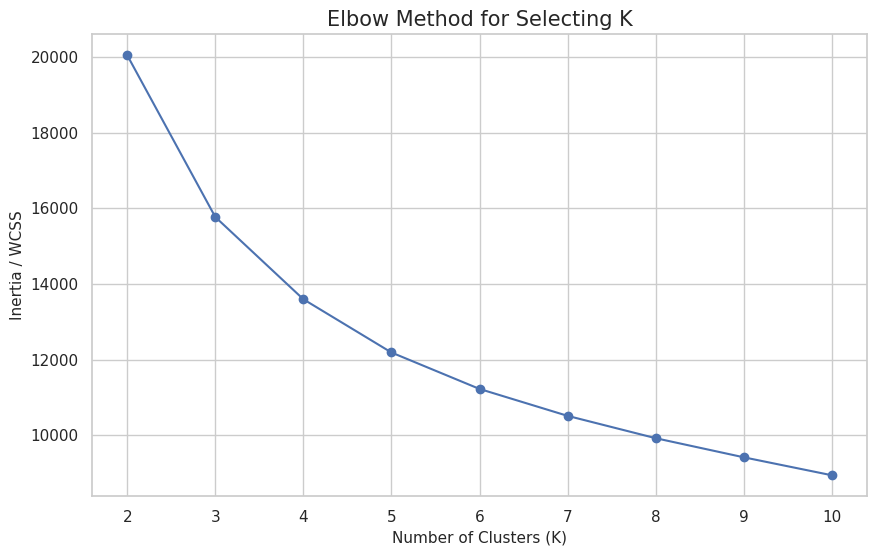

Selected K for the main analysis: 4


In [8]:
# ============================================================
# 8. ELBOW METHOD
# ============================================================
k_values = range(2, 11)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(list(k_values), inertias, marker="o")
plt.xticks(list(k_values))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method for Selecting K")
plt.show()

# Practical default. If the elbow is visually different on your run,
# change this single value and rerun the downstream cells.
K = 4
print(f"Selected K for the main analysis: {K}")


### Why K = 4?

For this practical, **K=4** is used as the working segmentation solution because it generally provides a useful business-oriented separation of customer behavior into a small number of interpretable groups.

The notebook also calculates silhouette scores for multiple K values so the choice can be checked quantitatively rather than relying only on the elbow plot.

,K,Silhouette Score
0,2,0.389112
1,3,0.305478
2,4,0.267546
3,5,0.234055
4,6,0.228594
5,7,0.228148
6,8,0.214385


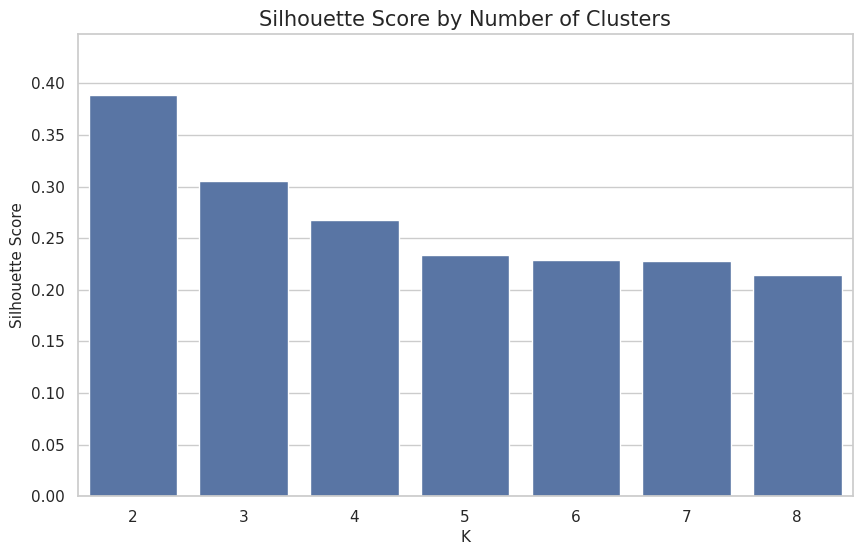

Highest tested silhouette score: K=2, score=0.3891


In [9]:
# ============================================================
# 9. SILHOUETTE ANALYSIS FOR MULTIPLE K VALUES
# ============================================================
silhouette_results = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    score_k = silhouette_score(X_scaled, labels_k)
    silhouette_results.append([k, score_k])

silhouette_df = pd.DataFrame(
    silhouette_results, columns=["K", "Silhouette Score"]
)

display(silhouette_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=silhouette_df, x="K", y="Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.ylim(0, max(0.1, silhouette_df["Silhouette Score"].max() * 1.15))
plt.show()

print(
    f"Highest tested silhouette score: "
    f"K={int(silhouette_df.loc[silhouette_df['Silhouette Score'].idxmax(), 'K'])}, "
    f"score={silhouette_df['Silhouette Score'].max():.4f}"
)


In [10]:
# ============================================================
# 10. FINAL K-MEANS SEGMENTATION
# ============================================================
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, customer_df["Cluster"])

print(f"Final K-Means silhouette score for K={K}: {final_silhouette:.4f}")

cluster_counts = customer_df["Cluster"].value_counts().sort_index()
display(cluster_counts.to_frame("Customers"))


Final K-Means silhouette score for K=4: 0.2675


,Customers
Cluster,
0,851
1,1554
2,794
3,1139


## 7. Hierarchical Clustering + Dendrogram

Hierarchical clustering is compared with K-Means.

Because a full dendrogram on thousands of customers can become computationally expensive and visually unreadable, a reproducible sample of customers is used for the dendrogram. The sample is large enough to show the hierarchical structure while keeping the notebook practical in Colab.

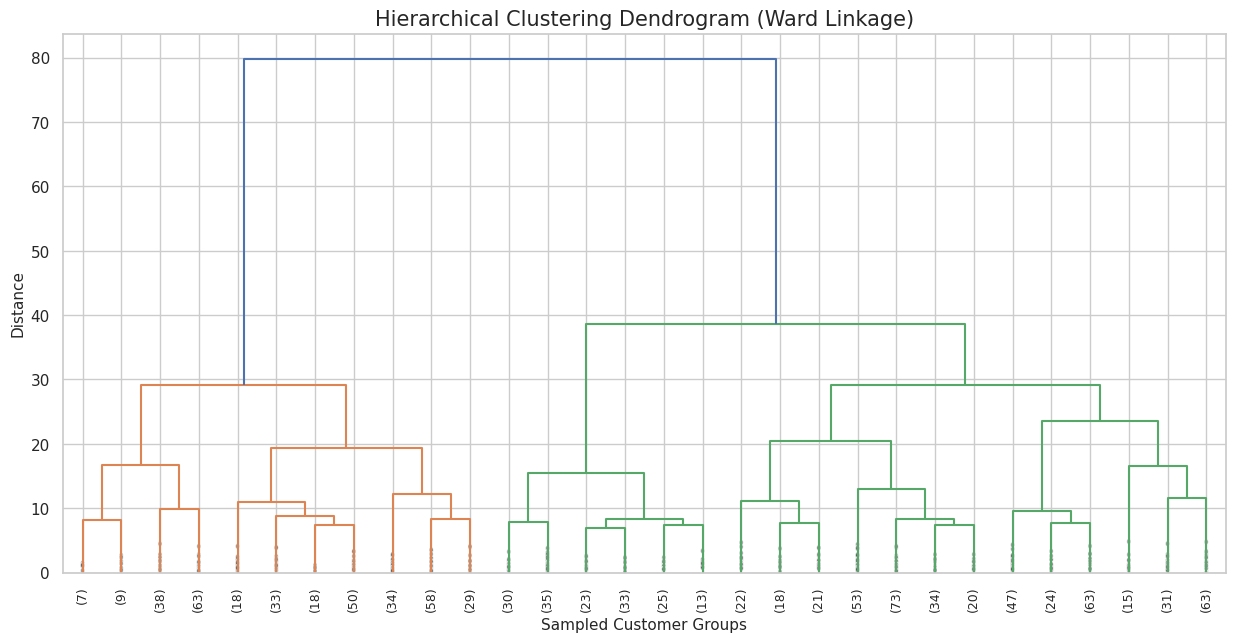

Hierarchical clustering silhouette score on the sampled customers: 0.2207


In [11]:
# ============================================================
# 11. HIERARCHICAL CLUSTERING + DENDROGRAM
# ============================================================
from scipy.cluster.hierarchy import linkage, dendrogram

HIER_SAMPLE_SIZE = min(1000, len(X_scaled))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=HIER_SAMPLE_SIZE, replace=False)
X_hier = X_scaled[sample_idx]

# Ward linkage works well with standardized Euclidean feature space
Z = linkage(X_hier, method="ward")

plt.figure(figsize=(15, 7))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sampled Customer Groups")
plt.ylabel("Distance")
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=K, linkage="ward")
hier_labels = hierarchical.fit_predict(X_hier)

hier_silhouette = silhouette_score(X_hier, hier_labels)

print(f"Hierarchical clustering silhouette score on the sampled customers: {hier_silhouette:.4f}")


## 8. Clustering Quality Comparison

Silhouette Score ranges from **-1 to +1**:
- values closer to **+1** indicate better separation
- values around **0** indicate overlapping clusters
- negative values indicate possible misassignment

The K-Means score is calculated on all customers, while the hierarchical score is calculated on the reproducible sample used for the dendrogram.

,Method,Silhouette Score
0,K-Means,0.267542
1,Hierarchical,0.220733


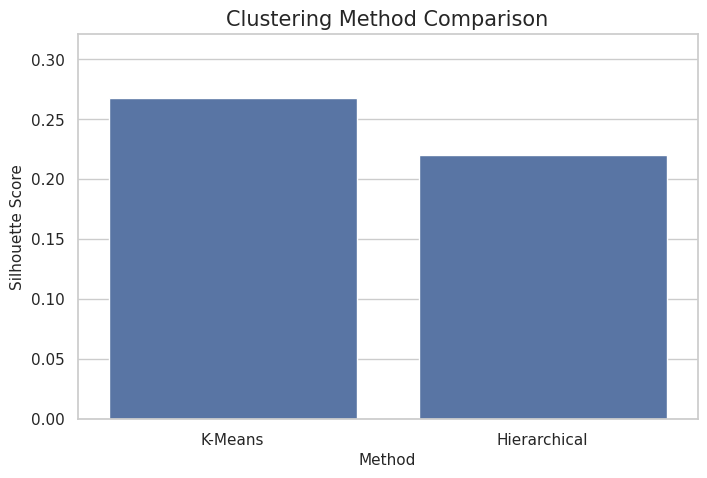

In [12]:
# ============================================================
# 12. CLUSTERING COMPARISON
# ============================================================
comparison_df = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical"],
    "Silhouette Score": [final_silhouette, hier_silhouette]
})

display(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Method", y="Silhouette Score")
plt.title("Clustering Method Comparison")
plt.ylim(0, max(0.1, comparison_df["Silhouette Score"].max() * 1.2))
plt.show()


## 9. PCA — 2D Customer Segment Visualization

PCA reduces the standardized customer feature space to two principal components for visualization.

The PCA plot does **not** replace the original clustering features; it provides a 2D visual representation of the segments.

PC1 explains 56.28% of variance
PC2 explains 19.46% of variance
Combined: 75.74%


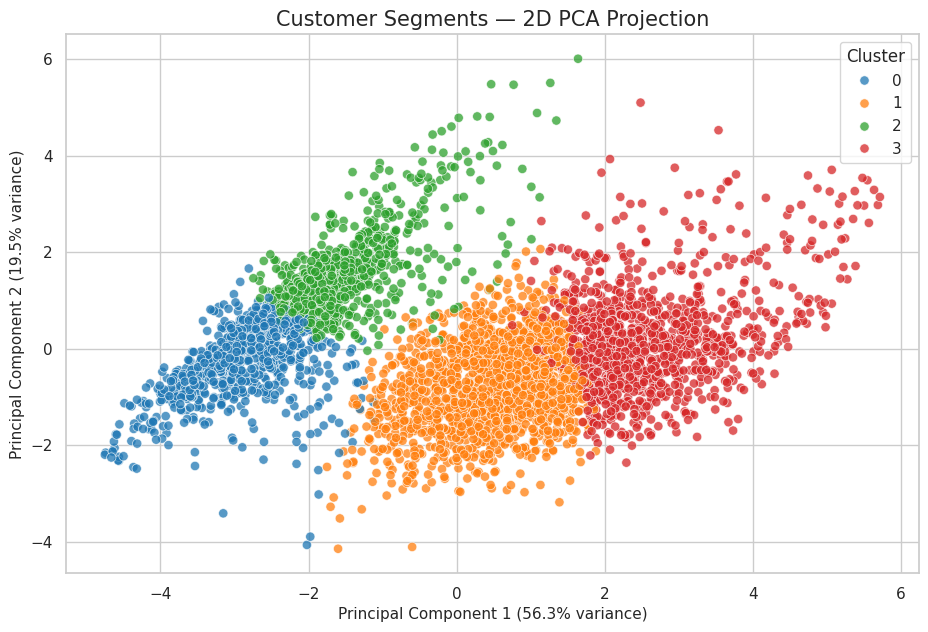

In [13]:
# ============================================================
# 13. PCA 2D VISUALIZATION
# ============================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

customer_df["PCA1"] = X_pca[:, 0]
customer_df["PCA2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained[0]:.2f}% of variance")
print(f"PC2 explains {explained[1]:.2f}% of variance")
print(f"Combined: {explained.sum():.2f}%")

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=customer_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    s=45,
    alpha=0.75
)
plt.title("Customer Segments — 2D PCA Projection")
plt.xlabel(f"Principal Component 1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({explained[1]:.1f}% variance)")
plt.legend(title="Cluster")
plt.show()


## 10. Cluster Profiling

We compare the original, interpretable customer features across clusters.

The segment with the highest average **Monetary Value** is designated as the **high-value customer segment** for the supervised-learning task.

Recency        Frequency        MonetaryValue           \
           mean median      mean median          mean   median   
Cluster                                                          
0        166.61  161.0      1.12    1.0        168.25   157.09   
1         73.20   46.5      3.21    3.0        785.78   708.80   
2        143.98  106.0      1.09    1.0        756.69   425.96   
3         27.71   16.0     10.29    7.0       6077.36  2874.72   

        AvgTransactionValue         TotalQuantity         AvgQuantity         \
                       mean  median          mean  median        mean median   
Cluster                                                                        
0                    155.91  151.05         91.14    82.0        9.44   6.89   
1                    264.46  232.62        446.77   388.0       12.07   8.83   
2                    677.26  406.28        472.55   264.5      132.23  11.64   
3                    641.22  416.45       3516.20  1739.0       56.01  12.09   

        PurchaseFrequency         ActiveDays         
                     mean  median       mean median  
Cluster                                              
0                  365.75  365.25       2.37    1.0  
1                   11.03    7.16     169.97  165.0  
2                  364.51  365.25       1.76    1.0  
3                   23.33   10.74     265.75  287.0

,Recency,Frequency,MonetaryValue,AvgTransactionValue,TotalQuantity,AvgQuantity,PurchaseFrequency,ActiveDays
Cluster,,,,,,,,
0,166.61,1.12,168.25,155.91,91.14,9.44,365.75,2.37
1,73.20,3.21,785.78,264.46,446.77,12.07,11.03,169.97
2,143.98,1.09,756.69,677.26,472.55,132.23,364.51,1.76
3,27.71,10.29,6077.36,641.22,3516.20,56.01,23.33,265.75


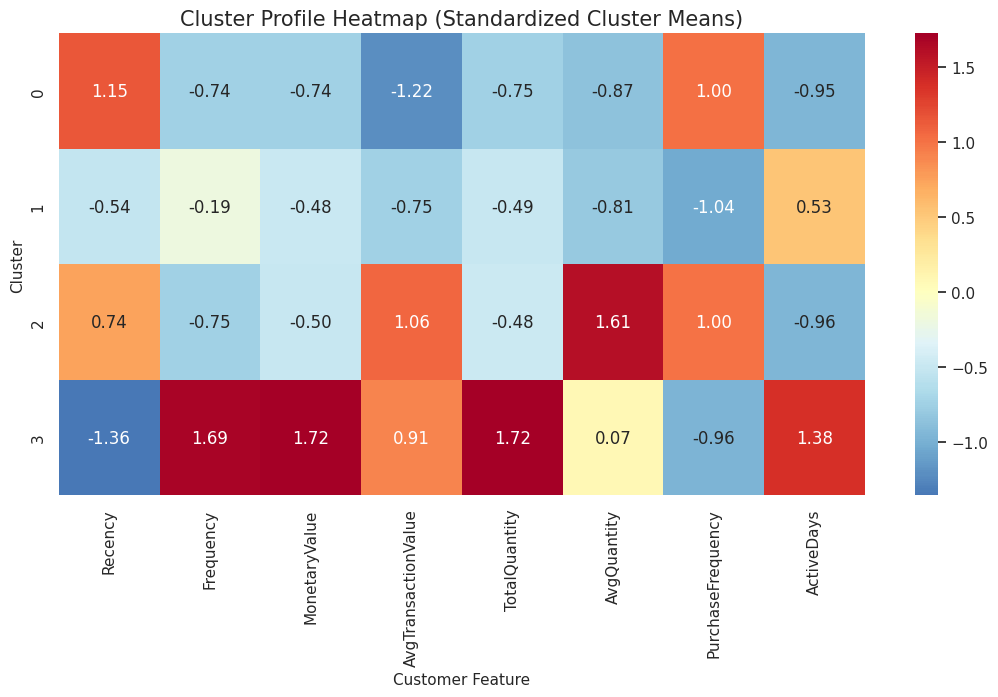

In [14]:
# ============================================================
# 14. CLUSTER-WISE CUSTOMER PROFILING
# ============================================================
profile_cols = [
    "Recency", "Frequency", "MonetaryValue",
    "AvgTransactionValue", "TotalQuantity",
    "AvgQuantity", "PurchaseFrequency", "ActiveDays"
]

cluster_profile = (
    customer_df.groupby("Cluster")[profile_cols]
    .agg(["mean", "median"])
    .round(2)
)

display(cluster_profile)

# Compact mean table for easy interpretation
cluster_means = (
    customer_df.groupby("Cluster")[profile_cols]
    .mean()
    .round(2)
)

display(cluster_means)

# Heatmap of normalized cluster means
profile_z = cluster_means.copy()
profile_z = (profile_z - profile_z.mean()) / profile_z.std(ddof=0)

plt.figure(figsize=(13, 6))
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0)
plt.title("Cluster Profile Heatmap (Standardized Cluster Means)")
plt.xlabel("Customer Feature")
plt.ylabel("Cluster")
plt.show()


In [15]:
# ============================================================
# 15. IDENTIFY HIGH-VALUE SEGMENT
# ============================================================
high_value_cluster = int(
    customer_df.groupby("Cluster")["MonetaryValue"].mean().idxmax()
)

customer_df["HighValue"] = (
    customer_df["Cluster"] == high_value_cluster
).astype(int)

high_value_size = int(customer_df["HighValue"].sum())
high_value_pct = customer_df["HighValue"].mean() * 100

print(f"High-value cluster: Cluster {high_value_cluster}")
print(f"Customers in high-value segment: {high_value_size:,}")
print(f"Share of customers: {high_value_pct:.2f}%")

hv_summary = (
    customer_df.groupby("HighValue")[profile_cols]
    .mean()
    .round(2)
)
hv_summary.index = ["Other Customers", "High-Value Customers"]
display(hv_summary)


High-value cluster: Cluster 3
Customers in high-value segment: 1,139
Share of customers: 26.26%


,Recency,Frequency,MonetaryValue,AvgTransactionValue,TotalQuantity,AvgQuantity,PurchaseFrequency,ActiveDays
Other Customers,115.62,2.13,614.29,338.04,358.56,41.19,193.13,83.63
High-Value Customers,27.71,10.29,6077.36,641.22,3516.20,56.01,23.33,265.75


## 11. Automatic Customer Segment Interpretation

The exact characteristics depend on the calculated cluster profiles. The code below generates a concise interpretation from the relative values of Recency, Frequency, and Monetary Value.

This keeps the final explanation tied to the actual dataset rather than hard-coding assumptions about the clusters.

In [16]:
# ============================================================
# 16. AUTOMATIC SEGMENT INTERPRETATION
# ============================================================
overall_means = customer_df[profile_cols].mean()

segment_descriptions = []

for cluster_id, row in cluster_means.iterrows():
    recency_label = "recent" if row["Recency"] < overall_means["Recency"] else "less recent"
    frequency_label = "frequent" if row["Frequency"] > overall_means["Frequency"] else "less frequent"
    monetary_label = "high spending" if row["MonetaryValue"] > overall_means["MonetaryValue"] else "lower spending"

    if cluster_id == high_value_cluster:
        business_label = "High-Value / Priority Customers"
    elif row["Recency"] < overall_means["Recency"] and row["Frequency"] > overall_means["Frequency"]:
        business_label = "Loyal / Active Customers"
    elif row["Recency"] > overall_means["Recency"] and row["Frequency"] < overall_means["Frequency"]:
        business_label = "At-Risk / Low-Engagement Customers"
    else:
        business_label = "Growth / Developing Customers"

    segment_descriptions.append({
        "Cluster": cluster_id,
        "Business Profile": business_label,
        "Behavior": f"{recency_label}, {frequency_label}, {monetary_label}"
    })

segment_description_df = pd.DataFrame(segment_descriptions)
display(segment_description_df)


,Cluster,Business Profile,Behavior
0,0,At-Risk / Low-Engagement Customers,"less recent, less frequent, lower spending"
1,1,Growth / Developing Customers,"recent, less frequent, lower spending"
2,2,At-Risk / Low-Engagement Customers,"less recent, less frequent, lower spending"
3,3,High-Value / Priority Customers,"recent, frequent, high spending"


## 12. Predicting High-Value Customers

The cluster-derived `HighValue` label becomes the target variable.

Two supervised models are trained:
1. **Random Forest Classifier**
2. **Support Vector Machine (SVM)**

The model input uses customer purchasing features. The target is created from the clustering result, so the task is interpreted as learning the purchasing pattern associated with the high-value segment.

In [17]:
# ============================================================
# 17. PREPARE SUPERVISED LEARNING DATA
# ============================================================
X = customer_df[feature_cols].copy()
y = customer_df["HighValue"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Scale for SVM and keep the preprocessing pipeline reproducible
supervised_scaler = StandardScaler()
X_train_scaled = supervised_scaler.fit_transform(np.log1p(X_train))
X_test_scaled = supervised_scaler.transform(np.log1p(X_test))

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTarget distribution:")
display(y.value_counts().rename(index={0: "Other", 1: "High-Value"}).to_frame("Customers"))


Training set: (3470, 8)
Testing set : (868, 8)

Target distribution:


,Customers
HighValue,
Other,3199
High-Value,1139


In [18]:
# ============================================================
# 18. RANDOM FOREST + SVM
# ============================================================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)

svm = SVC(
    kernel="rbf",
    C=2.0,
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
svm.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest and SVM trained successfully.")


✅ Random Forest and SVM trained successfully.


## 13. Classification Performance

Required metrics:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

Because the high-value segment may be smaller than the remaining customers, **Precision, Recall, F1, and ROC-AUC** are especially useful alongside Accuracy.

In [19]:
# ============================================================
# 19. MODEL EVALUATION
# ============================================================
def classification_metrics(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    classification_metrics("Random Forest", y_test, rf_pred, rf_prob),
    classification_metrics("SVM", y_test, svm_pred, svm_prob)
])

display(results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_pred, target_names=["Other", "High-Value"], zero_division=0))

print("\nSVM Classification Report")
print(classification_report(y_test, svm_pred, target_names=["Other", "High-Value"], zero_division=0))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9885,0.9866,0.9693,0.9779,0.9995
1,SVM,0.9862,0.9538,0.9956,0.9742,0.9998



Random Forest Classification Report
              precision    recall  f1-score   support

       Other       0.99      1.00      0.99       640
  High-Value       0.99      0.97      0.98       228

    accuracy                           0.99       868
   macro avg       0.99      0.98      0.99       868
weighted avg       0.99      0.99      0.99       868


SVM Classification Report
              precision    recall  f1-score   support

       Other       1.00      0.98      0.99       640
  High-Value       0.95      1.00      0.97       228

    accuracy                           0.99       868
   macro avg       0.98      0.99      0.98       868
weighted avg       0.99      0.99      0.99       868



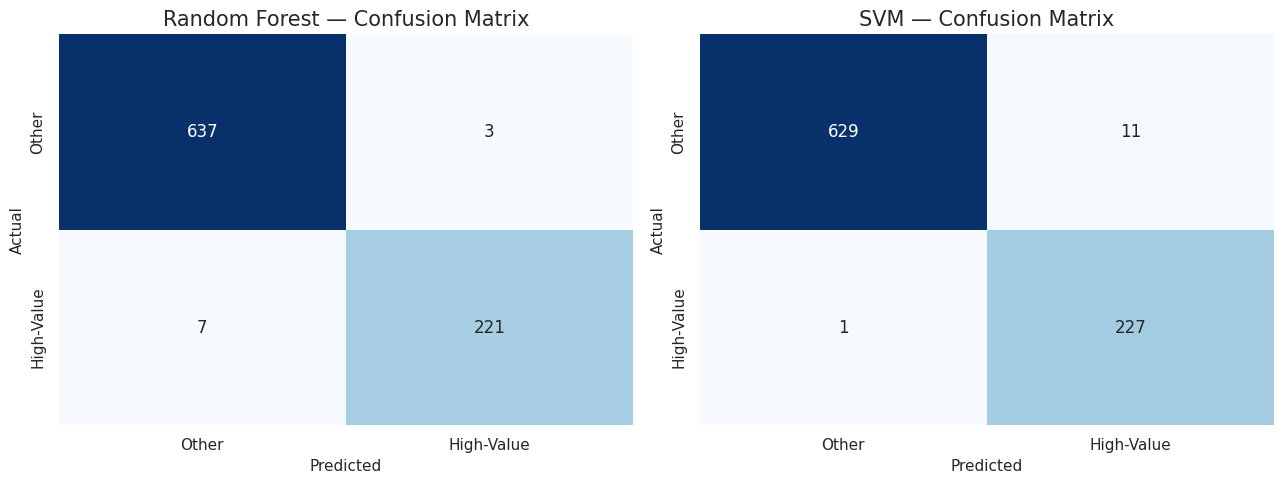

In [20]:
# ============================================================
# 20. CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title in [
    (axes[0], rf_pred, "Random Forest"),
    (axes[1], svm_pred, "SVM")
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Other", "High-Value"],
        yticklabels=["Other", "High-Value"]
    )
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


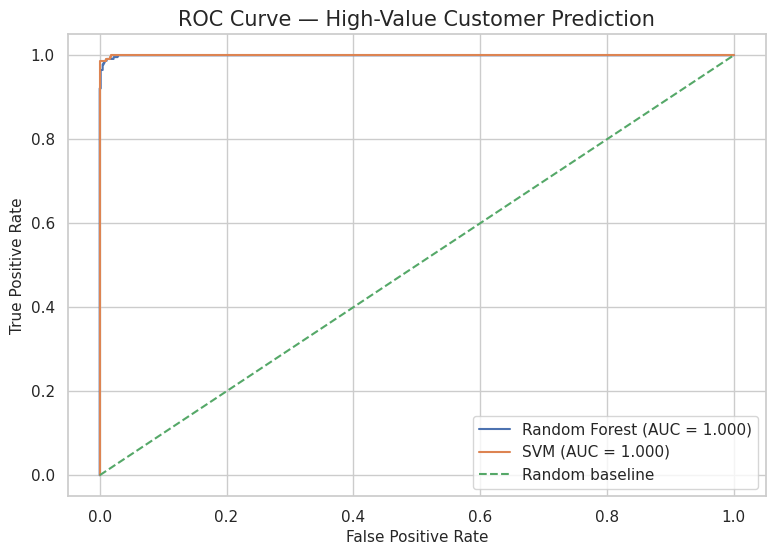

In [21]:
# ============================================================
# 21. ROC CURVES
# ============================================================
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)

plt.figure(figsize=(9, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {roc_auc_score(y_test, svm_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — High-Value Customer Prediction")
plt.legend()
plt.show()


## 14. Feature Importance Analysis

Random Forest provides a direct feature-importance measure based on impurity reduction.

To make the interpretation stronger, the notebook also calculates **permutation importance** on the test set. The latter measures how much model performance changes when a feature is randomly shuffled.

,Feature,Importance
2,MonetaryValue,0.356260
4,TotalQuantity,0.254075
1,Frequency,0.148461
7,ActiveDays,0.077708
0,Recency,0.051509
6,PurchaseFrequency,0.050143
3,AvgTransactionValue,0.039451
5,AvgQuantity,0.022393


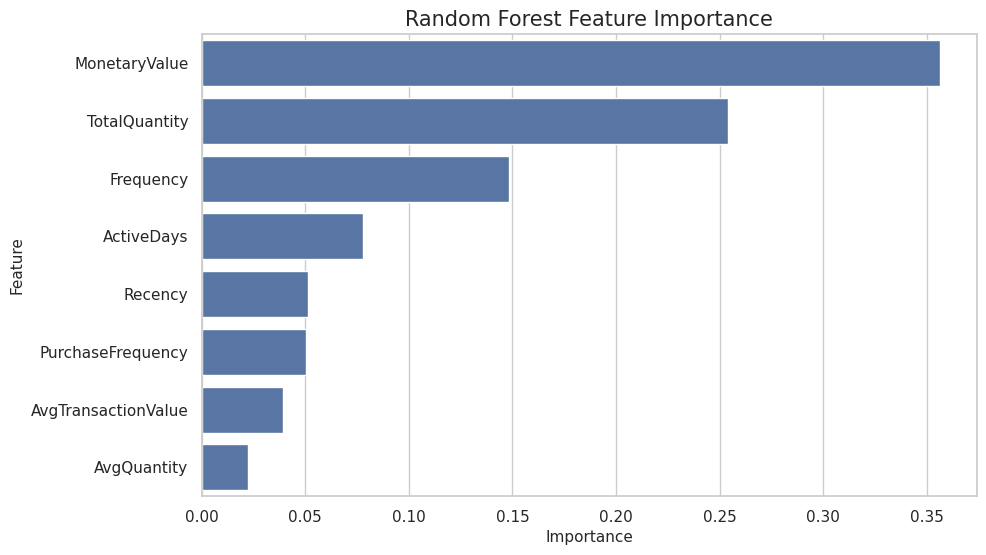

In [22]:
# ============================================================
# 22. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
rf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


,Feature,Mean Importance,Std
2,MonetaryValue,0.296771,0.020551
4,TotalQuantity,0.098394,0.010885
0,Recency,0.059628,0.007977
1,Frequency,0.031384,0.005019
7,ActiveDays,0.019292,0.006705
5,AvgQuantity,0.012810,0.003318
6,PurchaseFrequency,0.004063,0.002892
3,AvgTransactionValue,-0.000585,0.003626


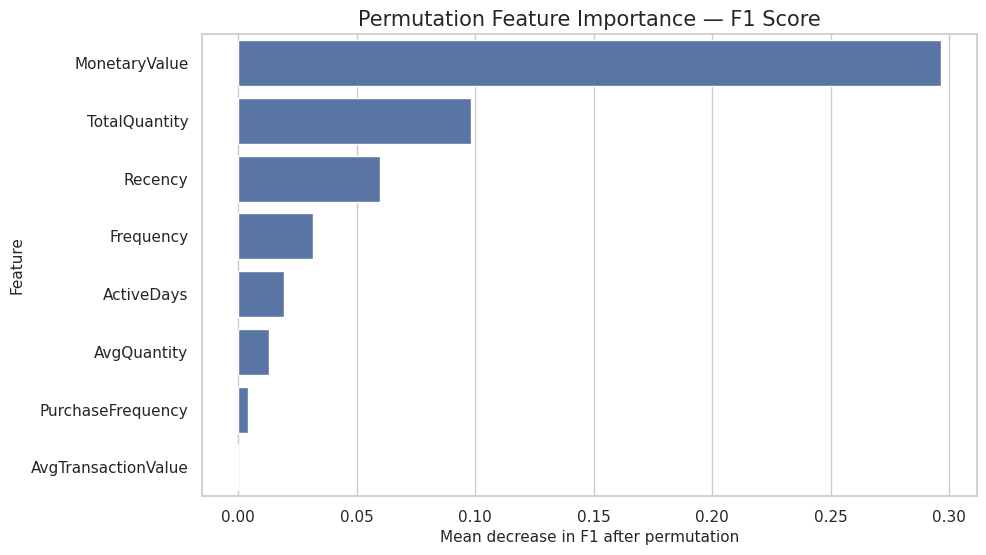

In [23]:
# ============================================================
# 23. PERMUTATION IMPORTANCE
# ============================================================
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Mean Importance", ascending=False)

display(perm_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df, x="Mean Importance", y="Feature")
plt.title("Permutation Feature Importance — F1 Score")
plt.xlabel("Mean decrease in F1 after permutation")
plt.ylabel("Feature")
plt.show()


## 15. Interactive 3D Customer Cluster Visualization

The practical explicitly requires an interactive 3D Plotly visualization.

Three principal components are used to project the standardized customer feature space into 3D while preserving as much variance as possible for visualization.

In [24]:
# ============================================================
# 24. PCA 3D + INTERACTIVE PLOTLY VISUALIZATION
# ============================================================
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_scaled)

customer_df["PCA1_3D"] = X_pca3[:, 0]
customer_df["PCA2_3D"] = X_pca3[:, 1]
customer_df["PCA3_3D"] = X_pca3[:, 2]

pca3_explained = pca3.explained_variance_ratio_ * 100
print(
    f"Variance explained by PC1/PC2/PC3: "
    f"{pca3_explained[0]:.2f}% / {pca3_explained[1]:.2f}% / {pca3_explained[2]:.2f}%"
)

plot_df = customer_df.copy()
plot_df["Cluster"] = plot_df["Cluster"].astype(str)

fig = px.scatter_3d(
    plot_df,
    x="PCA1_3D",
    y="PCA2_3D",
    z="PCA3_3D",
    color="Cluster",
    hover_data=["CustomerID", "Recency", "Frequency", "MonetaryValue", "HighValue"],
    title="Interactive 3D Customer Segmentation — PCA",
    opacity=0.75
)

fig.update_layout(
    width=1050,
    height=700,
    legend_title_text="Cluster"
)
fig.show()


Variance explained by PC1/PC2/PC3: 56.28% / 19.46% / 9.44%


## 16. Segment-Wise Marketing Recommendations

The recommendations below are generated from the observed behavioral profile of each cluster. They are business suggestions based on the analytical patterns, not assumptions about individual customers.

In [25]:
# ============================================================
# 25. MARKETING RECOMMENDATIONS
# ============================================================
def marketing_recommendation(row, overall):
    recency = row["Recency"]
    freq = row["Frequency"]
    monetary = row["MonetaryValue"]

    rec_high = recency < overall["Recency"]
    freq_high = freq > overall["Frequency"]
    money_high = monetary > overall["MonetaryValue"]

    if row.name == high_value_cluster:
        return "VIP treatment, loyalty rewards, premium bundles, early-access offers and personalized retention campaigns."
    elif rec_high and freq_high:
        return "Loyalty program, cross-sell/upsell campaigns, personalized recommendations and repeat-purchase incentives."
    elif not rec_high and not freq_high:
        return "Re-engagement campaigns, limited-time offers, personalized reminders and win-back incentives."
    elif money_high:
        return "High-ticket product recommendations, premium bundles and relationship-focused retention campaigns."
    else:
        return "Nurture campaigns, product discovery offers, targeted discounts and frequency-building promotions."

recommendation_rows = []

for cluster_id, row in cluster_means.iterrows():
    recommendation_rows.append({
        "Cluster": cluster_id,
        "Avg Recency": round(row["Recency"], 2),
        "Avg Frequency": round(row["Frequency"], 2),
        "Avg Monetary": round(row["MonetaryValue"], 2),
        "Customer Strategy": marketing_recommendation(row, overall_means)
    })

recommendation_df = pd.DataFrame(recommendation_rows)
display(recommendation_df)


,Cluster,Avg Recency,Avg Frequency,Avg Monetary,Customer Strategy
0,0,166.61,1.12,168.25,"Re-engagement campaigns, limited-time offers, ..."
1,1,73.20,3.21,785.78,"Nurture campaigns, product discovery offers, t..."
2,2,143.98,1.09,756.69,"Re-engagement campaigns, limited-time offers, ..."
3,3,27.71,10.29,6077.36,"VIP treatment, loyalty rewards, premium bundle..."


## 17. Final Results Dashboard

This section brings the major outputs together in one place for the practical record.

In [26]:
# ============================================================
# 26. FINAL RESULTS DASHBOARD
# ============================================================
print("=" * 75)
print("FINAL PRACTICAL RESULTS")
print("=" * 75)

print(f"Transactions after cleaning : {len(df_clean):,}")
print(f"Customers analyzed          : {len(customer_df):,}")
print(f"Selected K                  : {K}")
print(f"K-Means Silhouette Score    : {final_silhouette:.4f}")
print(f"Hierarchical Silhouette     : {hier_silhouette:.4f}")
print(f"High-Value Cluster          : {high_value_cluster}")
print(f"High-Value Customer Share   : {high_value_pct:.2f}%")

print("\nMODEL PERFORMANCE")
display(results)

print("\nTOP RANDOM FOREST FEATURES")
display(rf_importance.head(5))


FINAL PRACTICAL RESULTS
Transactions after cleaning : 392,692
Customers analyzed          : 4,338
Selected K                  : 4
K-Means Silhouette Score    : 0.2675
Hierarchical Silhouette     : 0.2207
High-Value Cluster          : 3
High-Value Customer Share   : 26.26%

MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.988479,0.986607,0.969298,0.977876,0.999537
1,SVM,0.986175,0.953782,0.995614,0.974249,0.999815



TOP RANDOM FOREST FEATURES


,Feature,Importance
2,MonetaryValue,0.356260
4,TotalQuantity,0.254075
1,Frequency,0.148461
7,ActiveDays,0.077708
0,Recency,0.051509


## 18. Interpretation & Conclusion

### Key analytical conclusions
- Transaction-level records were converted into customer-level behavioral features.
- Missing customer identifiers and invalid/cancelled transactions were handled before modeling.
- Outliers were controlled using percentile capping, followed by log transformation and standardization.
- K-Means was used for customer segmentation and the Elbow Method + Silhouette Score were used for cluster validation.
- Hierarchical clustering and a dendrogram provided a second view of the customer structure.
- PCA provided 2D and 3D representations of the customer segments.
- The cluster with the highest average monetary value was defined as the high-value segment.
- Random Forest and SVM were trained to predict membership in that high-value segment.
- Classification metrics and feature importance identify which customer behaviors are most useful for high-value prediction.
- Segment-specific marketing recommendations can then be designed around recency, frequency, spending, and purchase behavior.

### Final business interpretation
The analysis converts raw retail transactions into actionable customer segments. The resulting segments can support differentiated retention, loyalty, re-engagement, upselling, and customer-development strategies.